# Classification Models Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
# Check for missing values
missing_values = df.isnull().sum()

# Display columns with missing values and their counts
print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
Unnamed: 32    569
dtype: int64


In [3]:
# Drop the 'id' and 'Unnamed: 32' columns
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Display the first few rows of the DataFrame after dropping columns
display(df.head())

# Display the shape of the DataFrame to confirm column removal
print(f"Shape of the DataFrame after dropping columns: {df.shape}")

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Shape of the DataFrame after dropping columns: (569, 31)


/tmp/ipykernel_398/3970649813.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


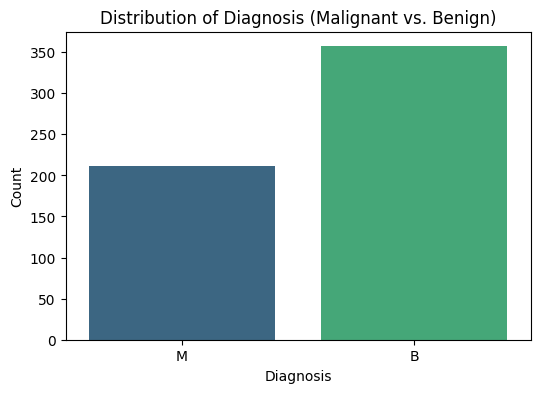

In [4]:
# Create a count plot for the 'diagnosis' column
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Distribution of Diagnosis (Malignant vs. Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [5]:
# Get the number of unique values in the 'diagnosis' column
unique_diagnosis_count = df['diagnosis'].nunique()
print(f"Number of unique values in 'diagnosis' column: {unique_diagnosis_count}")

# Also show the unique values themselves
print("Unique values in 'diagnosis' column:")
print(df['diagnosis'].unique())

Number of unique values in 'diagnosis' column: 2
Unique values in 'diagnosis' column:
['M' 'B']


In [6]:
# Convert categorical 'diagnosis' values to numerical (M=1, B=0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Display the first few rows to verify the conversion
display(df.head())

# Check the data type of the 'diagnosis' column to confirm conversion
print(f"Data type of 'diagnosis' column after conversion: {df['diagnosis'].dtype}")

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Data type of 'diagnosis' column after conversion: int64


In [7]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('diagnosis', axis=1) # All columns except 'diagnosis'
y = df['diagnosis'] # The 'diagnosis' column

# Split the data into training and testing sets
# Using a test size of 30% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (398, 30)
Shape of X_test: (171, 30)
Shape of y_train: (398,)
Shape of y_test: (171,)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200)

# Train the model on the training data
log_reg_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_log_reg = log_reg_model.predict(X_test)

# Calculate the accuracy of the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Logistic Regression Model Accuracy: {accuracy_log_reg:.4f}")

Logistic Regression Model Accuracy: 0.9649


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the K-Nearest Neighbors model
# A common choice for n_neighbors is 5, but it can be tuned
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model on the training data
knn_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_knn = knn_model.predict(X_test)

# Calculate the accuracy of the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")

K-Nearest Neighbors Model Accuracy: 0.9591


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Using a common n_estimators value (e.g., 100) and random_state for reproducibility
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Calculate the accuracy of the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Classifier Model Accuracy: {accuracy_rf:.4f}")

Random Forest Classifier Model Accuracy: 0.9708


In [11]:
from sklearn.svm import SVC

# Initialize the Support Vector Machine (SVM) model
# Using a common kernel (e.g., 'linear' or 'rbf') and random_state for reproducibility
# For simplicity, starting with a linear kernel. Further tuning can be done.
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test)

# Calculate the accuracy of the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Support Vector Machine (SVM) Model Accuracy: {accuracy_svm:.4f}")

Support Vector Machine (SVM) Model Accuracy: 0.9649


In [12]:
# Create a dictionary to store the accuracies of all models
model_accuracies = {
    "Logistic Regression": accuracy_log_reg,
    "K-Nearest Neighbors": accuracy_knn,
    "Random Forest": accuracy_rf,
    "Support Vector Machine": accuracy_svm
}

# Print the accuracies of all models
print("\n--- Model Accuracies ---")
for model_name, accuracy in model_accuracies.items():
    print(f"{model_name}: {accuracy:.4f}")

# Determine the best performing model
best_model_name = max(model_accuracies, key=model_accuracies.get)
best_accuracy = model_accuracies[best_model_name]

print(f"\n--- Best Performing Model ---")
print(f"The best model is {best_model_name} with an accuracy of {best_accuracy:.4f}")


--- Model Accuracies ---
Logistic Regression: 0.9649
K-Nearest Neighbors: 0.9591
Random Forest: 0.9708
Support Vector Machine: 0.9649

--- Best Performing Model ---
The best model is Random Forest with an accuracy of 0.9708
